# Interpolation
Interpolation is a mathematical technique used to estimate values between two known values. In the context of shapes, interpolation allows us to smoothly transform one shape into another by gradually blending their corresponding points. This process is widely used in computer graphics, animation, and data visualization to create smooth transitions and morphing effects.

## Morphing Example: Circle to Square

This example demonstrates how to morph (interpolate) between a circle and a square shape. The process involves gradually transforming the points of a circle into the corresponding points of a square, creating a smooth animation between the two shapes.

Below, you'll find code and visualizations illustrating this morphing process.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import FloatSlider, Output, VBox
from IPython.display import display

# Number of points for the shapes
n_points = 100

# Parameter t for the parametric equations.
# Start at -pi/4 (towards the lower right corner of the square) and go counter-clockwise.
t = np.linspace(-np.pi / 4, 7 * np.pi / 4, n_points, endpoint=False)
#np.random.shuffle(t)
# Circle coordinates
circle_x = np.cos(t)
circle_y = np.sin(t)

# Square coordinates, each side traversed counter-clockwise like the circle
points_per_side = n_points // 4
s = np.linspace(-1, 1, points_per_side, endpoint=False)
one = np.ones(points_per_side)
right = np.column_stack((one, s))
top = np.column_stack((-s, one))
left = np.column_stack((-one, -s))
bottom = np.column_stack((s, -one))

#Combine all sides to form the full square
square_points = np.vstack((right, top, left, bottom)) # Change the order of stacking and see the effect.

# Extract x and y coordinates for the square
square_x = square_points[:, 0]
square_y = square_points[:, 1]

morph_out = Output()

def show_figure(fig, out):
    """Put the figure in the output widget 'out', replacing the previous one."""
    plt.close(fig)  # the widget shows the figure, so the notebook should not show it too
    data, metadata = get_ipython().display_formatter.format(fig)
    out.outputs = ({'output_type': 'display_data', 'data': data, 'metadata': metadata},)

def morph_shape(alpha):
    x = (1 - alpha) * circle_x + alpha * square_x
    y = (1 - alpha) * circle_y + alpha * square_y
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.plot(x, y, 'o', label=f'alpha={alpha:.2f}')
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal')
    ax.set_title('Morphing: Circle to Square')
    ax.legend()
    show_figure(fig, morph_out)

slider = FloatSlider(value=0.0, min=0.0, max=1.0, step=0.01, description='alpha')
slider.observe(lambda change: morph_shape(change['new']), names='value')
morph_shape(slider.value)
display(VBox([slider, morph_out]))

**Task:** Change the order of the stacking of the sides of the square and see the effect. 

Morphing images can be done in the same manner. 

In [2]:
import requests
from PIL import Image
from io import BytesIO
import numpy as np
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt

# URLs of the portrait images
url_dog = "https://unsplash.com/photos/x5oPmHmY3kQ/download?ixid=M3wxMjA3fDB8MXxzZWFyY2h8Mnx8ZG9nJTIwcG9ydHJhaXR8ZW58MHx8fHwxNzU5MDg1MzAxfDA&force=true&w=640"
url_cat = "https://images.pexels.com/photos/34065256/pexels-photo-34065256.jpeg" 
url_face =  "https://images.unsplash.com/photo-1507003211169-0a1dd7228f2d"
url_building= "https://images.pexels.com/photos/10040106/pexels-photo-10040106.jpeg" 

url1=url_face
url2=url_cat
# Function to download and return an image
def download_image(url):
    response = requests.get(url)
    response.raise_for_status()
    image = Image.open(BytesIO(response.content)).convert("RGB")
    return image

# Download both images
img1 = download_image(url1)
img2 = download_image(url2)

# Shrink the first image so the blending is fast
img1.thumbnail((600, 600))

# Resize second image to match the first
img2 = img2.resize(img1.size)

# Convert images to numpy arrays
arr1 = np.array(img1, dtype=np.float32)
arr2 = np.array(img2, dtype=np.float32)
# Function to display morphed image based on interpolation factor
image_out = widgets.Output()

def show_morphed_image(alpha):
    blended = (1 - alpha) * arr1 + alpha * arr2
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(np.uint8(blended))
    ax.axis('off')
    ax.set_title(f"Interpolation α = {alpha:.2f}")
    show_figure(fig, image_out)

# Create interactive slider
slider = widgets.FloatSlider(value=0., min=0.0, max=1.0, step=0.05, description='α:', continuous_update=False)
slider.observe(lambda change: show_morphed_image(change['new']), names='value')
show_morphed_image(slider.value)
display(widgets.VBox([slider, image_out]))


### Why is morphing interpolation?

Linear interpolation between two known values $A$ and $B$ is

$$
P(\alpha) = (1-\alpha)\,A + \alpha\,B, \qquad 0 \le \alpha \le 1 .
$$

It reproduces the data, $P(0) = A$ and $P(1) = B$, and fills in the values in between.

The morphing examples use exactly this formula. The only difference is that $A$ and $B$ are not single numbers: for the shapes they are the coordinates of 100 points, and for the images they are the colour values of every pixel. The formula is applied to each point (or pixel) separately, with the same $\alpha$ for all of them.

This is also the simplest case of the Lagrange interpolation we meet below. Take two nodes, $\alpha_0 = 0$ and $\alpha_1 = 1$, with data $A$ and $B$. The Lagrange basis polynomials are

$$
\ell_0(\alpha) = \frac{\alpha - 1}{0 - 1} = 1 - \alpha, \qquad
\ell_1(\alpha) = \frac{\alpha - 0}{1 - 0} = \alpha ,
$$

so $P(\alpha) = A\,\ell_0(\alpha) + B\,\ell_1(\alpha)$ is the interpolating polynomial of degree 1 through the two "data points" $(0, A)$ and $(1, B)$.

Note that the formula only blends *pairs*: point number $i$ on the circle is blended with point number $i$ on the square. Which points are paired is our choice, not part of the interpolation, and that is why the order of the square's sides changes the morph so much.


## Background theory
**Weierstrass Approximation Theorem:**  
Every continuous function defined on a closed interval $[a, b]$ can be uniformly approximated as closely as desired by a polynomial function.

**Horner's Method:**  
Horner's method is an efficient algorithm to evaluate polynomials at a given point.  
For a polynomial $ P(x) = a_n x^n + \dots + a_1 x + a_0 $, Horner's form rewrites it as 

$$
P(x) = (\dots((a_n x + a_{n-1}) x + a_{n-2}) \dots x + a_0)
$$  
which reduces the number of multiplications required.


In [3]:
def horner(a, x):
    """Evaluate the polynomial using Horner's rule:
    p(x) = a(0) + a(1)x + ... + a(n-1)x^(n-1)
    """
    n = len(a)
    p = a[-1]
    for k in range(2, n + 1):
        p = p * x + a[-k]
    return p

def direct(a, x):
    """Evaluate the polynomial term by term:
    p(x) = a(0) + a(1)x + ... + a(n-1)x^(n-1)
    """
    p = 0
    for k in range(len(a)):
        p = p + a[k] * x**k
    return p

# Small example: −x**2 + 2x + 4 at x = 3
a = [4, 2, -1]
x = 3
n = len(a)
print(f"Horner's method evaluation: {horner(a, x)}")
print(f"Direct evaluation: {direct(a, x)}")
print(f"Horner uses {n - 1} multiplications and {n - 1} additions")
print(f"Direct uses {n*(n-1)//2} multiplications and {n-1} additions")  

Horner's method evaluation: 1
Direct evaluation: 1
Horner uses 2 multiplications and 2 additions
Direct uses 3 multiplications and 2 additions


**Task: Is Horner's method also faster?**

Horner's method uses $n$ multiplications to evaluate a polynomial of degree $n$. If we instead compute each term $a_k x^k$ separately, building $x^k$ by multiplying $x$ with itself $k$ times, we need $1 + 2 + \dots + n = \frac{n(n+1)}{2}$ multiplications.

1. Write a function `naive(a, x)` that evaluates the polynomial term by term, where each power $x^k$ is computed with a loop of repeated multiplications (do not use `x**k`). Check that it gives the same value as `horner(a, x)` for the small example above.
2. Before you measure anything: if the degree is doubled, how much longer do you expect `horner` to take? And `naive`?
3. For the degrees $n = 10, 20, 50, 100, 200, 400, 800$, make a polynomial with random coefficients and measure the time of one evaluation with both functions. Use $x = 0.9$.
4. Plot the two times against $n$ with `plt.loglog`. What are the slopes of the two lines, and how do they relate to the number of multiplications?
5. Repeat the measurement with the function `direct(a, x)`, which uses `x**k`. Why is it much closer to Horner's method than `naive` is?

*Hints:*
- `rng = np.random.default_rng(0)` and `a = rng.standard_normal(n + 1).tolist()` give random coefficients.
- `min(timeit.repeat(lambda: horner(a, 0.9), number=100, repeat=5)) / 100` gives a stable time for one evaluation. Use a smaller `number` for `naive` at high degree.
- Use a decimal number close to 1 for $x$. A large $x$ overflows for high degrees, and an integer $x$ makes Python use very large integers, which disturbs the timing.


## Lagrange Interpolation Polynomials

**Lagrange interpolation** is a classical method for constructing a polynomial that passes exactly through a given set of data points. Given $n+1$ distinct data points $(x_0, y_0), (x_1, y_1), \ldots, (x_n, y_n)$, the Lagrange interpolating polynomial $P(x)$ of degree at most $n$ is defined as:

$$
P(x) = \sum_{j=0}^{n} y_j \ell_j(x)
$$

where each $\ell_j(x)$ is the **Lagrange basis polynomial**:

$$
\ell_j(x) = \prod_{\substack{0 \leq m \leq n \\ m \neq j}} \frac{x - x_m}{x_j - x_m}
$$

### Properties

- $\ell_j(x_k) = 1$ if $j = k$, and $0$ otherwise.
- Each $\ell_j(x)$ is a polynomial of degree $n$.
- The interpolating polynomial $P(x)$ passes through all the given points: $P(x_j) = y_j$ for all $j$.
- The method is **exact** for polynomials of degree up to $n$.

Each $\ell_j(x)$ "picks out" the value $y_j$ at $x_j$ and is zero at all other nodes. The shape of the $\ell_j(x)$ polynomials shows how each node influences the interpolation at different $x$ values.

### Advantages

- Simple, explicit formula.
- No need to solve a system of equations.

### Disadvantages

- Computationally expensive for large $n$.
- Susceptible to **Runge’s phenomenon** (oscillations) for high-degree polynomials on equidistant nodes. This is a property of the interpolating polynomial itself, not of the Lagrange form.

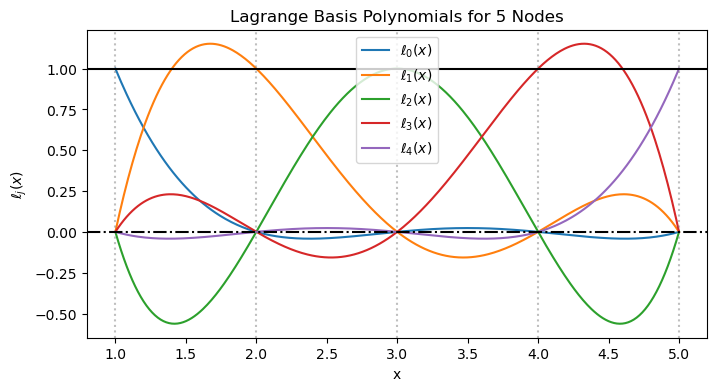

In [4]:
# Plot the Lagrange basis polynomials l_j(x) for 5 equidistant nodes
def lagrange_basis(x_nodes, j, x):
    """Compute the j-th Lagrange basis polynomial at x."""
    basis = 1
    n = len(x_nodes)
    for m in range(n):
        if m != j:
            basis *= (x - x_nodes[m]) / (x_nodes[j] - x_nodes[m])
    return basis

x_nodes=[1, 2., 3, 4, 5]
x_values = np.linspace(1, 5, 400)
plt.figure(figsize=(8, 4))
for j in range(len(x_nodes)):
    l_j = [lagrange_basis(x_nodes, j, xi) for xi in x_values]
    plt.plot(x_values, l_j, label=rf'$\ell_{j}(x)$')
for node in x_nodes:
    plt.axvline(node, color='gray', linestyle=':', alpha=0.5, linewidth=1.5)
plt.axhline(1, color='black', linewidth=1.5)
plt.axhline(0, color='black', linewidth=1.5,linestyle='-.')
plt.xlabel('x')
plt.ylabel(r'$\ell_j(x)$')
plt.title('Lagrange Basis Polynomials for 5 Nodes')
plt.legend()
plt.grid(False)
plt.show()

**Tasks:** 

- The figure only shows the $x$-interval of the nodes. What happens outside of that interval?
- The figure has equidistant nodes. Can you define nodes that are not equidistant?

### Example 2 p 194
Consider the function $f(x) = \sqrt{x}$ at the points $x = 1, 2, 3$.  
We want to construct the interpolating polynomial that passes through the points:

| $x$ | $f(x)$   |
|-----|----------|
| 1   | 1.0000   |
| 2   | 1.4142   |
| 3   | 1.7321   |

To construct the interpolating polynomial, we use the Lagrange interpolation formula:

$$
P(x) = \sum_{j=0}^{2} f(x_j) \ell_j(x)
$$

where the Lagrange basis polynomials are:

- $\ell_0(x) = \dfrac{(x-2)(x-3)}{(1-2)(1-3)}=\dfrac{1}{2}(x-2)(x-3)$

- $\ell_1(x) = \dfrac{(x-1)(x-3)}{(2-1)(2-3)}=-(x-1)(x-3)$

- $\ell_2(x) = \dfrac{(x-1)(x-2)}{(3-1)(3-2)}=\dfrac{1}{2}(x-1)(x-2)$

Plugging in the function values:

- $f(1) = 1.0000$
- $f(2) = 1.4142$
- $f(3) = 1.7321$

So,

$$
\begin{align*}
P(x) =\ & 1.0000 \cdot \dfrac{1}{2} (x-2)(x-3)\\
&- 1.4142 \cdot (x-1)(x-3) \\
&+ 1.7321 \cdot \dfrac{1}{2}(x-1)(x-2)
\end{align*}
$$

Expanding and simplifying gives the explicit quadratic polynomial that interpolates the points.

In [5]:
def lagrange_interpolating_polynomial(x_points, y_points):
    """
    Returns a function representing the Lagrange interpolating polynomial
    for the given data points (x_points, y_points).
    """
    def P(x):
        total = 0
        n = len(x_points)
        for j in range(n):
            # Compute the j-th Lagrange basis polynomial
            lj = 1
            for m in range(n):
                if m != j:
                    lj *= (x - x_points[m]) / (x_points[j] - x_points[m])
            total += y_points[j] * lj
        return total
    return P

In [6]:
p=lagrange_interpolating_polynomial([1, 2, 3], [np.sqrt(1), np.sqrt(2), np.sqrt(3)])
print(f"Type of p: {type(p)}")
print(f"Value of p at x=2.5: {p(2.5)}")

Type of p: <class 'function'>
Value of p at x=2.5: 1.5851792246181504


In [7]:
x = 1.2 # Try the nodes 1, 2, 3 and see that p(x) = sqrt(x)
p(x) - np.sqrt(x)

-0.004892297161527948

To add another point x=1.2, f(1.2)=$\sqrt{1.2}$ we need to make a new function


In [8]:
p1=lagrange_interpolating_polynomial([1, 1.2, 2, 3], [np.sqrt(1), np.sqrt(1.2), np.sqrt(2), np.sqrt(3)])
p1(x) - np.sqrt(x)

0.0

**Tasks** Look at the error outside of the data points, for instance x=4. 

Let's plot the results. 

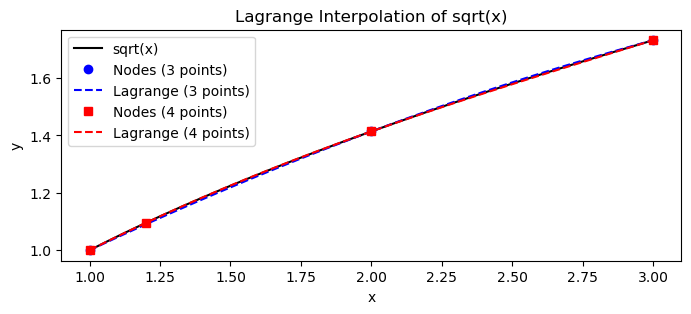

In [9]:
x = np.linspace(1, 3, 400)
plt.figure(figsize=(8, 3))
# Plot the true function
plt.plot(x, np.sqrt(x), label='sqrt(x)', color='black')
# Plot the nodes for 3-point interpolation
x_nodes_3 = [1, 2, 3]
y_nodes_3 = np.sqrt(x_nodes_3)
p3=lagrange_interpolating_polynomial(x_nodes_3, y_nodes_3)
plt.plot(x_nodes_3, y_nodes_3, 'o', label='Nodes (3 points)', color='blue')
# Plot the 3-point interpolation
plt.plot(x, p3(x), label='Lagrange (3 points)', color='blue', linestyle='--')
# Plot the nodes for 4-point interpolation
x_nodes_4 = [1, 1.2, 2, 3]
y_nodes_4 = np.sqrt(x_nodes_4)
p4 = lagrange_interpolating_polynomial(x_nodes_4, y_nodes_4)
plt.plot(x_nodes_4, y_nodes_4, 's', label='Nodes (4 points)', color='red')
# Plot the 4-point interpolation
plt.plot(x, p4(x), label='Lagrange (4 points)', color='red', linestyle='--')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Lagrange Interpolation of sqrt(x)')
plt.legend()
plt.show()

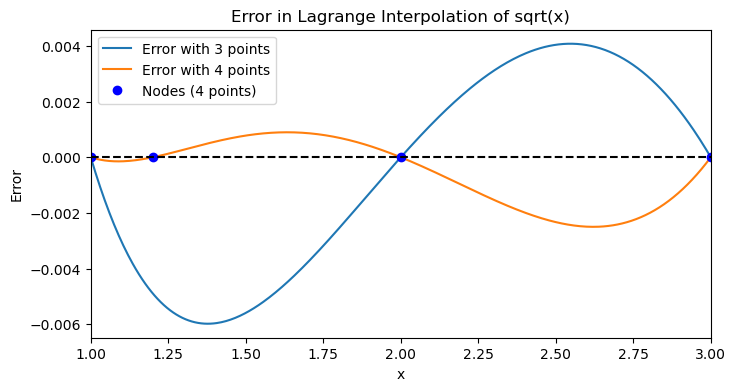

In [10]:
x = np.linspace(1, 3, 400)
plt.figure(figsize=(8, 4))
plt.plot(x, p3(x) - np.sqrt(x), label='Error with 3 points')
plt.plot(x, p4(x) - np.sqrt(x), label='Error with 4 points')
plt.plot(x_nodes_4, [0]*len(x_nodes_4), 'o', label='Nodes (4 points)', color='blue')
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('x')
plt.ylabel('Error')
plt.title('Error in Lagrange Interpolation of sqrt(x)')
plt.xlim(1, 3)
plt.legend();


**Tasks** Extend the x interval beyond the interval $x\in [1,3]$. 

### Reproducing figure 6.1
Remember that 
$$
 f(x)-p(x)=\frac{L(x)}{(N+1)!}f^{(N+1)}(\xi)
$$ with
$$
 L(x)= \prod_{k=0}^{N} (x-x_k)
$$

In figure 6.1 the function $L(x)=(x-1)(x-1.5)(x-2)(x-2.5)(x-3)$. 

The nodes for this interpolation are $x = 1,\, 1.5,\, 2,\, 2.5,\, 3$. 

These are the points where the polynomial $L(x)$ is zero, and they define the interval of interest for the interpolation. Inside $[1, 3]$ the polynomial $L(x)$ stays small, but it is larger in the two end subintervals than in the middle. With more equidistant nodes this difference grows, which is the mechanism behind Runge's phenomenon: the interpolation error is largest near the endpoints. Outside the interval, $|L(x)|$ grows rapidly, which is why extrapolation with the interpolating polynomial is unreliable.


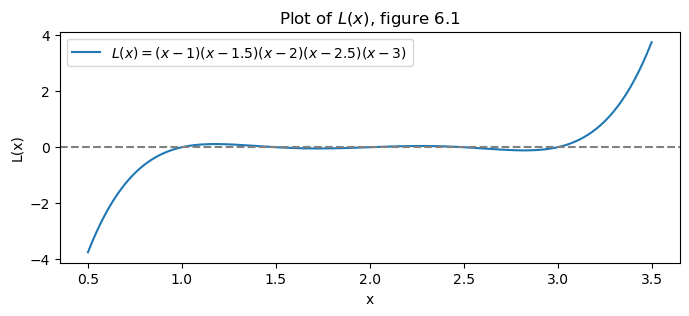

In [11]:
L = lambda x: (x - 1) * (x - 1.5) * (x - 2) * (x - 2.5) * (x - 3)
x_L = np.linspace(0.5, 3.5, 400) # Try (1,3) and (0,4)
plt.figure(figsize=(8, 3))
plt.plot(x_L, L(x_L), label=r'$L(x)=(x-1)(x-1.5)(x-2)(x-2.5)(x-3)$')
plt.xlabel('x')
plt.ylabel('L(x)')
plt.title('Plot of $L(x)$, figure 6.1')
plt.axhline(0, color='gray', linestyle='--')
plt.legend()
plt.show()

**Task:** Zoom in on $x\in [1,3]$, then add new nodes at your own choice in the interval. You can use the code below. 

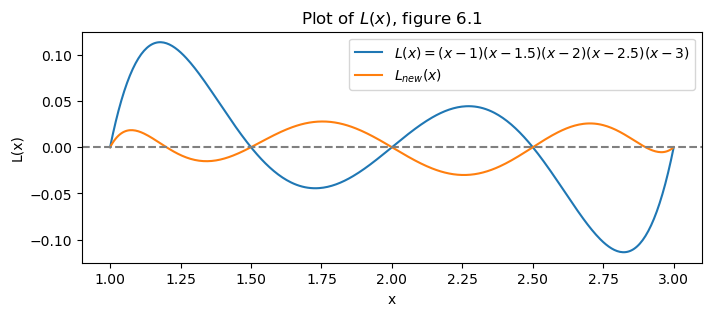

In [12]:
L = lambda x: (x - 1) * (x - 1.5) * (x - 2) * (x - 2.5) * (x - 3)
L_new = lambda x: (x - 1) * (x - 1.2) * (x - 1.5) * (x - 2) * (x - 2.5) *(x - 2.9) * (x - 3)
x_L = np.linspace(1, 3, 400) # Try (1,3) and (0,4)
plt.figure(figsize=(8, 3))
plt.plot(x_L, L(x_L), label=r'$L(x)=(x-1)(x-1.5)(x-2)(x-2.5)(x-3)$')
plt.plot(x_L, L_new(x_L), label=r'$L_{new}(x)$')
plt.xlabel('x')
plt.ylabel('L(x)')
plt.title('Plot of $L(x)$, figure 6.1')
plt.axhline(0, color='gray', linestyle='--')
plt.legend()
plt.show()

### Example: Lagrange Interpolation for Runge’s Function

Runge’s function is defined as:

$$
f(x) = \frac{1}{1 + x^2}
$$

Let's interpolate this function using Lagrange interpolation with equidistant nodes and compare the interpolation to the true function.


In [13]:
from ipywidgets import IntSlider

# Define Runge's function
def runge(x):
    return 1 / (1 + x**2)

# Choose equidistant nodes
def plot_runge_interpolation(num_nodes):
    x_nodes = np.linspace(-5, 5, num_nodes)
    y_nodes = runge(x_nodes)
    p_runge = lagrange_interpolating_polynomial(x_nodes, y_nodes)
    x = np.linspace(-5, 5, 400)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(x, runge(x), label="Runge's Function", color='black')
    ax.plot(x, p_runge(x), label=f'Lagrange Interpolation ({num_nodes} points)', linestyle='--', color='red')
    ax.scatter(x_nodes, y_nodes, color='blue', zorder=5, label='Interpolation Nodes')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title("Runge's Function and Its Lagrange Interpolation")
    ax.legend()
    show_figure(fig, runge_out)

runge_out = Output()
runge_slider = IntSlider(value=2, min=2, max=20, step=1, description='Nodes')
runge_slider.observe(lambda change: plot_runge_interpolation(change['new']), names='value')
plot_runge_interpolation(runge_slider.value)
display(VBox([runge_slider, runge_out]))


## Difference Representation


Difference representation such as Newton's divided differences
is a good approach to interpolation for several reasons:

- **Efficiency for Adding Points:** When a new data point is added, you do not need to recompute the entire polynomial from scratch. You can update the divided difference table incrementally.
- **Computational Simplicity:** The polynomial can be evaluated efficiently using nested multiplication (Horner's method).
- **Flexibility:** The method works well for both evenly and unevenly spaced data points.

In summary, difference representation makes polynomial interpolation more efficient and flexible, especially when working with many or changing data points.

Functions to calculate the divided difference and subsequent evaluation of the polynomial. 

In [14]:
# Function to compute divided differences
def newton_divided_diff(x, y):
    n = len(x)
    D = np.zeros((n, n))
    for j in range(n):
        D[j, 0] = y[j]
    for j in range(1, n):
        for i in range(n - j):
            D[i, j] = (D[i + 1, j - 1] - D[i, j - 1]) / (x[i + j] - x[i])
    coef = D[0, :]  # Coefficients are in the first row
    return D

# Function to evaluate Newton's polynomial at x
def newton_poly(coef, x_data, x):
    n = len(coef)
    p = coef[-1]
    for k in range(2, n+1):
        p = coef[-k] + (x - x_data[-k]) * p
    return p



### Example: Newton's Divided Differences

Given the data points:

| $k$ | $x_k$ | $f(x_k)$ |
|-----|-------|----------|
| 0   | 2     | 4        |
| 1   | 3     | 2        |
| 2   | 5     | 1        |

Let's compute the divided difference table and write the Newton interpolating polynomial.


- Zeroth order (function values):
    - $f[x_0] = f(2) = 4$
    - $f[x_1] = f(3) = 2$
    - $f[x_2] = f(5) = 1$

- First order:
    - $f[x_0, x_1] = \dfrac{f[x_1] - f[x_0]}{x_1 - x_0} = \dfrac{2 - 4}{3 - 2} = -2$
    
    - $f[x_1, x_2] = \dfrac{f[x_2] - f[x_1]}{x_2 - x_1} = \dfrac{1 - 2}{5 - 3} = -0.5$

- Second order:
    - $f[x_0, x_1, x_2] = \dfrac{f[x_1, x_2] - f[x_0, x_1]}{x_2 - x_0} = \dfrac{-0.5 - (-2)}{5 - 2} = \dfrac{1.5}{3} = 0.5$



In [15]:
x_nodes = np.array([2,3,5])
y_nodes = np.array([4,2,1])
D = newton_divided_diff(x_nodes, y_nodes)
D

array([[ 4. , -2. ,  0.5],
       [ 2. , -0.5,  0. ],
       [ 1. ,  0. ,  0. ]])

**Task**: What happens if you add a point to the data, say $(x,y)=(7,0)$ or $(x,y)=(2.5,3)$?


### Example 5: Newton’s Divided Difference Interpolation for $\sqrt{0.3}$ and $\sqrt{1.1}$

Given data:

| $x$   | $0.2$   | $0.6$   | $1.2$   | $1.5$   |
|-------|---------|---------|---------|---------|
| $\sqrt{x}$ | $0.4472$ | $0.7746$ | $1.0954$ | $1.2247$ |

We want to estimate $\sqrt{0.3}$ and $\sqrt{1.1}$ using Newton’s divided difference formula.

**Step 1: Prepare the data**


Let  
$x_{\text{data}} = [0.2, 0.6, 1.2, 1.5]$  
$y_{\text{data}} = [0.4472, 0.7746, 1.0954, 1.2247]$


In [16]:
# Given data
x_data = np.array([0.2, 0.6, 1.2, 1.5])
y_data = np.array([0.4472, 0.7746, 1.0954, 1.2247])


**Step 2: Compute the divided difference table and interpolate**


In [17]:
import math
# Compute coefficients
D = newton_divided_diff(x_data, y_data)
coef = D[0, :]  # Coefficients are in the first row
print("Divided Difference Table D:")
print(D)


# Estimate sqrt(0.3) and sqrt(1.1)
x_vals = [0.3, 1.1]
estimates = [newton_poly(coef, x_data, xv) for xv in x_vals]
for i, xv in enumerate(x_vals):
    print(f"Estimated sqrt({xv}): {estimates[i]:.6f}")
    print(f"Actual sqrt({xv}): {math.sqrt(xv):.6f}")
    print(f"Error: {estimates[i] - math.sqrt(xv):.6f}")
    




Divided Difference Table D:
[[ 0.4472      0.8185     -0.28383333  0.12972934]
 [ 0.7746      0.53466667 -0.11518519  0.        ]
 [ 1.0954      0.431       0.          0.        ]
 [ 1.2247      0.          0.          0.        ]]
Estimated sqrt(0.3): 0.541068
Actual sqrt(0.3): 0.547723
Error: -0.006655
Estimated sqrt(1.1): 1.050287
Actual sqrt(1.1): 1.048809
Error: 0.001478


### Sorting the data points
Turner now turns to a way of avoiding polynomials of high degree, to avoid fluctuations between the nodes. The function below is an adjusted version of their code. It sorts the data points by distance to the point we want to evaluate, so that the nearest points are used first. For $x = 1.1$ and the data above, the order becomes $1.2,\ 1.5,\ 0.6,\ 0.2$.

In [18]:
# The function from Turner, p. 204
def ddiff1(xdat, ydat, x, max_degree=None, sort=True):
    """
    Function for computing Newton's divided difference formula using nearest data points in
    'xdat', 'ydat' to elements of 'x' first. Taken from Turner, p. 204.
    Input:
      xdat, ydat : data points for interpolation, dimensions M
      x          : points to evaluate the interpolation at, dimension N
    Output:
      y          : interpolated values at points in x
      D          : divided difference table
    Altered to allow for a maximum degree 'max_degree' of the polynomial
    (default: use all data points).
    """
    N = x.size
    M = xdat.size
    D = np.zeros((M, M))
    y = np.zeros(N)
    # A polynomial of degree d uses d + 1 data points (terms in Newton's formula)
    if max_degree is not None and max_degree + 1 < M:
        n_terms = max_degree + 1
    else:
        n_terms = M
    for k in range(N):
        # Sort contents of input data arrays
        xtst = x[k]
        if sort is False:
            xsort = xdat
            D[:, 0] = ydat
        else:
            ind = np.argsort(np.abs(xtst - xdat))
            xsort = xdat[ind]
            D[:, 0] = ydat[ind]
        # Begin divided differences
        for j in range(M - 1):
            for i in range(M - j - 1):
                D[i, j + 1] = (D[i + 1, j] - D[i, j]) / (xsort[i + j + 1] - xsort[i])
        # End divided differences
        # Compute interpolation
        xdiff = xtst - xsort
        prod = 1  # Holds the product of xdiff
        for i in range(n_terms):
            y[k] = y[k] + prod * D[0, i]
            prod = prod * xdiff[i]
    return y, D

In [19]:
# Compute the divided difference interpolation
x_eval = np.asarray(x_vals)
x_target = x_eval[:2]
print(f"Estimating sqrt({x_target[0]}) using divided differences:")
Y, D = ddiff1(x_data, y_data, x_target, max_degree=2, sort=True)
print("Divided Difference Table D:")
print(D)

print(f"Estimated sqrt({x_target[0]}): {Y[0]:.6f}")
print(f"Actual sqrt({x_target[0]}): {np.sqrt(x_target[0]):.6f}")

Estimating sqrt(0.3) using divided differences:
Divided Difference Table D:
[[ 1.0954      0.431      -0.11518519  0.12972934]
 [ 1.2247      0.50011111 -0.24491453  0.        ]
 [ 0.7746      0.8185      0.          0.        ]
 [ 0.4472      0.          0.          0.        ]]
Estimated sqrt(0.3): 0.537565
Actual sqrt(0.3): 0.547723


**Why is the estimate of $\sqrt{0.3}$ worse than before?**

With `max_degree=2` only the three nearest data points are used, so we get a polynomial of degree 2 instead of the cubic through all four points. Comparing the two (error is estimate minus exact value):

| | nearest 3 points (degree 2) | all 4 points (degree 3) |
|---|---|---|
| $\sqrt{0.3}$ | $0.537565$, error $-0.0102$ | $0.541068$, error $-0.0067$ |
| $\sqrt{1.1}$ | $1.047693$, error $-0.0011$ | $1.050287$, error $+0.0015$ |

Note first that sorting alone changes nothing. The interpolating polynomial through a given set of points is unique, so with all four points `ddiff1` gives the same values as `newton_poly` above, whatever the order. The difference comes from *dropping* the point farthest away.

The error formula tells us what dropping a point does. Going from three to four points multiplies the factor in front of the derivative by

$$
\frac{|x - x_{\text{new}}|}{4},
$$

and replaces $f'''(\xi)$ by $f^{(4)}(\xi)$.

- For $x = 0.3$ the dropped point is $1.5$, and the factor is $1.2/4 = 0.3$. The fourth point makes this part of the error smaller, even though it is far away. The fourth derivative of $\sqrt{x}$ is larger than the third near $x = 0.2$, which eats up some of the gain, but the cubic still wins.
- For $x = 1.1$ the dropped point is $0.2$, and the factor is $0.9/4 \approx 0.2$. Here the derivative costs more than the factor gains: with the point $0.2$ included, $\xi$ can lie anywhere in $[0.2, 1.5]$ instead of $[0.6, 1.5]$, and the derivatives of $\sqrt{x}$ grow quickly towards $x = 0$. The two estimates are about equally good, and the quadratic is slightly better.

So using fewer points is not more accurate in itself. A point far away still carries information about a smooth function. Using only the nearest points pays off when there are *many* data points, where a polynomial through all of them has high degree and may oscillate between the nodes. That is the situation in Runge's example below.

### Runge's example (revisited)


We return to Runge's function $f(x) = 1/(1+x^2)$ on $[-5, 5]$ with equidistant nodes, now using `ddiff1`. There are two sliders:

- `x_points` is the number of nodes.
- `max_degree` is the highest degree allowed. For each $x$ the function uses the `max_degree + 1` nodes nearest to that $x$.

If `max_degree` is at least `x_points - 1`, all nodes are used for every $x$. The result is then the same polynomial as in the Lagrange example above, since the interpolating polynomial is unique. With 11 nodes and `max_degree` = 10 we get one polynomial of degree 10, with large oscillations near the endpoints.

If `max_degree` is smaller, different $x$ use different sets of nodes. The curve is then no longer one polynomial, but a **piecewise polynomial**: a new polynomial of low degree takes over each time the set of nearest nodes changes.

Try this, with `x_points` = 11:

1. Set `max_degree` to 10 and lower it step by step. What happens to the oscillations near $x = \pm 5$?
2. Compare `max_degree` = 2 and `max_degree` = 3 near $x = \pm 0.5$. Which of the curves is continuous?

In [20]:
from ipywidgets import IntSlider
x_dense = np.linspace(-5, 5, 400)
y_dense = 1 / (1 + x_dense**2)
def plot_newton_interp(num_points,max_degree=4):
    x_points = np.linspace(-5, 5, num_points)
    y_points = 1 / (1 + x_points**2)
    y_interp, D = ddiff1(x_points, y_points, x_dense, max_degree=max_degree, sort=True)
    fig, (ax, ax_err) = plt.subplots(2, 1, figsize=(8, 5), sharex=True, height_ratios=[2, 1])
    ax.plot(x_points, y_points, 'o', label='Interpolation nodes')
    ax.plot(x_dense, y_interp, '--', label='Newton interp.')
    ax.plot(x_dense, y_dense, '-', label='y = 1/(1 + x^2)')
    ax.set_title('Function y = 1/(1 + x^2)')
    ax.set_ylabel('y')
    ax.legend()
    # Error in the lower plot. The y-axis rescales, so read off the size of the error there.
    error = y_interp - y_dense
    ax_err.plot(x_dense, error, 'x',color='C1',  label='Error')
    ax_err.plot(x_points, 0 * x_points, 'o', color='C0')
    ax_err.axhline(0, color='gray', linestyle='--')
    ax_err.set_title(f'Error, largest absolute value {np.max(np.abs(error)):.3f}')
    ax_err.set_xlabel('x')
    ax_err.set_ylabel('Error')
    fig.tight_layout()
    show_figure(fig, newton_out)

newton_out = Output()
points_slider = IntSlider(value=11, min=2, max=20, step=1, description='x_points')
degree_slider = IntSlider(value=1, min=1, max=20, step=1, description='max_degree')

def update_newton_plot(change=None):
    plot_newton_interp(points_slider.value, degree_slider.value)

points_slider.observe(update_newton_plot, names='value')
degree_slider.observe(update_newton_plot, names='value')
update_newton_plot()
display(VBox([points_slider, degree_slider, newton_out]))


**What we see**

With 11 nodes, the largest error on $[-5, 5]$ is:

| `max_degree` | largest error | continuous? |
|---|---|---|
| 1 | $0.067$ | yes |
| 2 | $0.073$ | no, jumps up to $0.15$ |
| 3 | $0.020$ | yes |
| 4 | $0.055$ | no, jumps up to $0.085$ |
| 5 | $0.021$ | yes |
| 10 (all nodes) | $1.9$ | yes |

- **Low degree removes Runge's phenomenon.** The polynomial of degree 10 is wrong by almost 2 near the endpoints, while the piecewise cubic is within $0.02$ everywhere. The error formula explains it: with only a few nodes, all close to $x$, the product $L(x)$ has few factors and all of them are small, so it never gets the chance to grow towards the endpoints.
- **Even degrees give jumps.** An even degree uses an odd number of nodes. Between two neighbouring nodes, the set of nearest nodes then changes at the *midpoint*, and the old and the new polynomial do not agree there. With `max_degree` = 2 the curve jumps by $0.15$ at $x = \pm 0.5$.
- **Odd degrees are continuous, but have kinks.** An odd degree uses an even number of nodes, the same number on each side of $x$ (except near the endpoints). The set of nodes then changes *at* a node, where the old and the new polynomial both equal the data value. The curve is continuous, but its derivative is not. With `max_degree` = 1 this is just straight lines between the data points.
- **Higher degree is not always better.** Degree 5 is no more accurate than degree 3 here.

So low-degree pieces are the cure for the oscillations, but the pieces do not fit smoothly together. Splines, in the next section, fix this: they also use a cubic on each interval, but choose the cubics so that the first and second derivatives are continuous at the nodes as well.

**Task:** Use the error plot to find the `max_degree` that gives the smallest largest error, for 11 nodes and for 20 nodes. Is it the same degree in both cases?

## Splines

Splines are a powerful family of piecewise polynomial functions used for interpolation and smoothing of data. Unlike high-degree global polynomials, which can oscillate wildly between data points (especially with many equidistant points), splines construct smooth curves by joining low-degree polynomials at specified points called **knots**. The most common type, the **cubic spline**, ensures that the resulting curve is not only continuous but also has continuous first and second derivatives, producing a visually smooth and stable interpolation.

**Key features of splines:**
- **Piecewise polynomial:** The domain is divided into intervals, with a separate polynomial on each interval.
- **Smoothness:** Splines are constructed so that the curve and its derivatives up to a certain order are continuous at the knots.
- **Stability:** Splines avoid the oscillatory behavior of high-degree polynomials, making them ideal for practical interpolation and data fitting.

Splines are widely used in computer graphics, engineering, data science, and numerical analysis for tasks such as curve fitting, animation, and numerical solutions to differential equations.

### Cubic splines

Let the nodes be $x_0 < x_1 < \dots < x_N$ with data $y_0, \dots, y_N$. A cubic spline $s(x)$ is a cubic polynomial $s_k(x)$ on each interval $[x_k, x_{k+1}]$, $k = 0, \dots, N-1$. Each cubic has 4 coefficients, so there are $4N$ unknowns. They are determined by the following conditions:

| Condition | Where | Number |
|---|---|---|
| Interpolation: $s_k(x_k) = y_k$ and $s_k(x_{k+1}) = y_{k+1}$ | every interval | $2N$ |
| Continuous first derivative: $s_{k-1}'(x_k) = s_k'(x_k)$ | interior nodes | $N-1$ |
| Continuous second derivative: $s_{k-1}''(x_k) = s_k''(x_k)$ | interior nodes | $N-1$ |

That is $4N - 2$ conditions, so two are missing. They are supplied as **boundary conditions**, and there are several common choices:

- **Natural:** $s''(x_0) = s''(x_N) = 0$.
- **Clamped:** $s'(x_0)$ and $s'(x_N)$ are given, for instance from $f'$ if it is known.
- **Not-a-knot:** the third derivative is also continuous at $x_1$ and $x_{N-1}$, so the first two intervals share one cubic, and so do the last two. This is the default in `scipy.interpolate.CubicSpline`.

Compare with the piecewise cubic in the previous section. There, each cubic was determined by four data values near $x$, and nothing was left to make the pieces fit together. In a spline each cubic only interpolates *two* data values, and the remaining freedom is used for smoothness.

The price is that the cubics can no longer be found one at a time. The smoothness conditions tie neighbouring pieces together, and we must solve a linear system for all of them at once. The system is tridiagonal, so this is cheap, with work proportional to $N$.

Largest error, polynomial of degree 10: 1.916
Largest error, piecewise cubic:         0.020
Largest error, cubic spline:            0.022


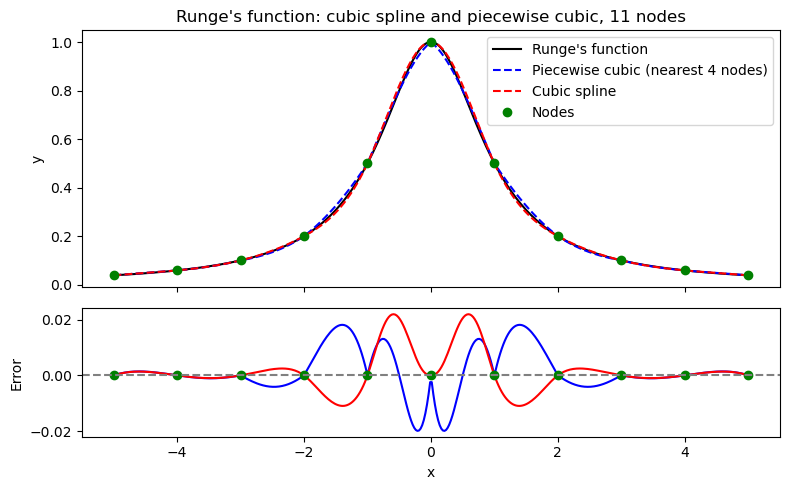

In [21]:
from scipy.interpolate import CubicSpline

x_nodes = np.linspace(-5, 5, 11)
y_nodes = runge(x_nodes)
x_dense = np.linspace(-5, 5, 400)
y_true = runge(x_dense)

# Cubic spline through the nodes
cs = CubicSpline(x_nodes, y_nodes)
y_spline = cs(x_dense)
# Piecewise cubic from the previous section: the 4 nearest nodes for each x
y_piecewise, D = ddiff1(x_nodes, y_nodes, x_dense, max_degree=3)
# One polynomial of degree 10 through all the nodes
y_poly = lagrange_interpolating_polynomial(x_nodes, y_nodes)(x_dense)

print(f"Largest error, polynomial of degree 10: {np.max(np.abs(y_poly - y_true)):.3f}")
print(f"Largest error, piecewise cubic:         {np.max(np.abs(y_piecewise - y_true)):.3f}")
print(f"Largest error, cubic spline:            {np.max(np.abs(y_spline - y_true)):.3f}")

fig, (ax, ax_err) = plt.subplots(2, 1, figsize=(8, 5), sharex=True, height_ratios=[2, 1])
ax.plot(x_dense, y_true, label="Runge's function", color='black')
ax.plot(x_dense, y_piecewise, '--', label='Piecewise cubic (nearest 4 nodes)', color='blue')
ax.plot(x_dense, y_spline, '--', label='Cubic spline', color='red')
ax.plot(x_nodes, y_nodes, 'o', label='Nodes', color='green')
ax.set_ylabel('y')
ax.set_title("Runge's function: cubic spline and piecewise cubic, 11 nodes")
ax.legend()
ax_err.plot(x_dense, y_piecewise - y_true, color='blue')
ax_err.plot(x_dense, y_spline - y_true, color='red')
ax_err.plot(x_nodes, 0 * x_nodes, 'o', color='green')
ax_err.axhline(0, color='gray', linestyle='--')
ax_err.set_xlabel('x')
ax_err.set_ylabel('Error')
fig.tight_layout()
plt.show()

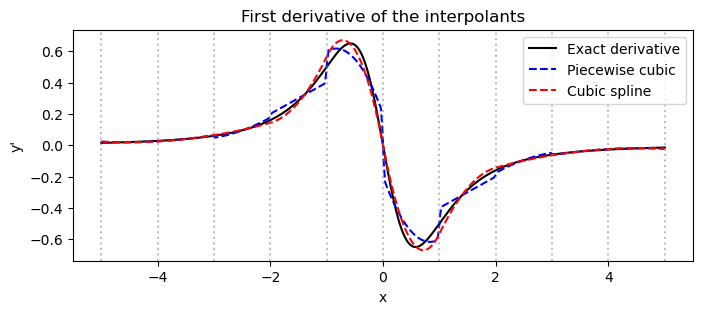

In [22]:
# First derivative: exact, spline, and piecewise cubic (numerical derivative of the curve)
dy_true = -2 * x_dense / (1 + x_dense**2)**2
dy_spline = cs(x_dense, 1)  # cs(x, 1) is the first derivative of the spline
dy_piecewise = np.gradient(y_piecewise, x_dense)

plt.figure(figsize=(8, 3))
plt.plot(x_dense, dy_true, label="Exact derivative", color='black')
plt.plot(x_dense, dy_piecewise, '--', label='Piecewise cubic', color='blue')
plt.plot(x_dense, dy_spline, '--', label='Cubic spline', color='red')
for node in x_nodes:
    plt.axvline(node, color='gray', linestyle=':', alpha=0.5)
plt.xlabel('x')
plt.ylabel("y'")
plt.title('First derivative of the interpolants')
plt.legend()
plt.show()

**What we see**

- The spline and the piecewise cubic are about equally accurate, with largest errors $0.022$ and $0.020$. Both are far better than the polynomial of degree 10. The spline is *not* the more accurate of the two here. What it gives us is smoothness.
- The derivative of the piecewise cubic jumps at the nodes, most clearly at $x = \pm 1$ and $x = \pm 2$. The derivative of the spline is continuous, as the conditions require.

**Tasks:**

1. `cs(x_dense, 2)` and `cs(x_dense, 3)` give the second and third derivative of the spline. Plot them. Which of them is continuous? Explain the shape of both from the fact that $s$ is a cubic on each interval.
2. `CubicSpline(x_nodes, y_nodes, bc_type='natural')` gives a natural spline. Does the choice of boundary condition matter for Runge's function?
3. Repeat task 2 for $g(x) = e^{x/3}$ on the same nodes. Where is the error of the natural spline largest, and why? *Hint:* what is $g''(\pm 5)$?

### How fast does the error decrease?

With one polynomial through all the nodes, more equidistant nodes made the error for Runge's function *larger*. For a spline, more nodes means shorter intervals, while the degree stays at 3. Let $h$ be the distance between the nodes. Below we double the number of intervals $N$ several times, so that $h$ is halved each time.

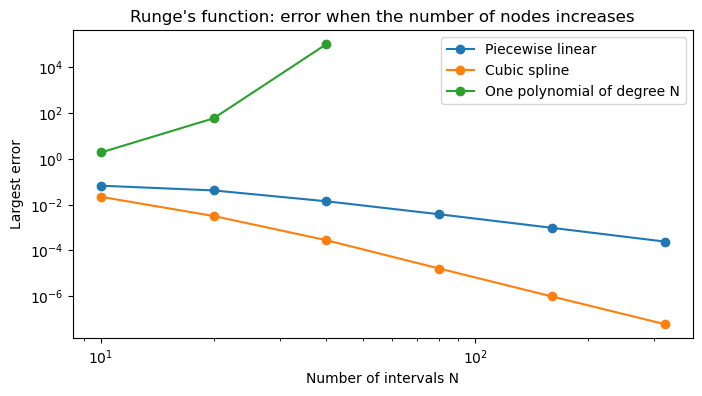

Error is divided by this factor each time N is doubled:
  Piecewise linear: [1.6 3.  3.7 3.9 4. ]
  Cubic spline:     [ 6.9 11.5 17.3 16.7 16.2]


In [23]:
# Largest error as a function of the number of intervals N (N + 1 equidistant nodes)
x_fine = np.linspace(-5, 5, 4001)
y_fine = runge(x_fine)
N_values = [10, 20, 40, 80, 160, 320]
err_spline = []
err_linear = []
for N in N_values:
    x_nodes = np.linspace(-5, 5, N + 1)
    y_nodes = runge(x_nodes)
    err_spline.append(np.max(np.abs(CubicSpline(x_nodes, y_nodes)(x_fine) - y_fine)))
    err_linear.append(np.max(np.abs(np.interp(x_fine, x_nodes, y_nodes) - y_fine)))

# One polynomial through all the nodes, only for the smallest N
N_poly = [10, 20, 40]
err_poly = []
for N in N_poly:
    x_nodes = np.linspace(-5, 5, N + 1)
    p = lagrange_interpolating_polynomial(x_nodes, runge(x_nodes))
    err_poly.append(np.max(np.abs(p(x_fine) - y_fine)))

plt.figure(figsize=(8, 4))
plt.loglog(N_values, err_linear, 'o-', label='Piecewise linear')
plt.loglog(N_values, err_spline, 'o-', label='Cubic spline')
plt.loglog(N_poly, err_poly, 'o-', label='One polynomial of degree N')
plt.xlabel('Number of intervals N')
plt.ylabel('Largest error')
plt.title("Runge's function: error when the number of nodes increases")
plt.legend()
plt.show()

print("Error is divided by this factor each time N is doubled:")
print("  Piecewise linear:", np.round(np.array(err_linear[:-1]) / np.array(err_linear[1:]), 1))
print("  Cubic spline:    ", np.round(np.array(err_spline[:-1]) / np.array(err_spline[1:]), 1))

Once $N$ is large enough, each doubling of $N$ divides the error of the cubic spline by about $16 = 2^4$, and the error of the piecewise linear interpolant by about $4 = 2^2$. In the log-log plot these are straight lines with slopes $-4$ and $-2$:

$$
\text{error}_{\text{linear}} \approx C h^2, \qquad \text{error}_{\text{cubic spline}} \approx C h^4 .
$$

The polynomial through all the nodes goes the other way, and the error has passed $10^4$ at $N = 40$.

This is the main message of this notebook. Weierstrass' theorem promises that a good polynomial approximation exists, but interpolation in many equidistant nodes does not find it. Keeping the degree low and making the intervals short does.

### Splines of other degrees

The same idea works for other degrees. A spline of degree 1 is straight lines between the data points, and a spline of degree 0 is constant on each interval. The function `interp1d` gives these with `kind='zero'`, `'linear'`, `'quadratic'` and `'cubic'`.

*Note:* `interp1d` is a legacy function in SciPy and is no longer developed. For new code, use `CubicSpline`, or `make_interp_spline(x, y, k=degree)` for other degrees.

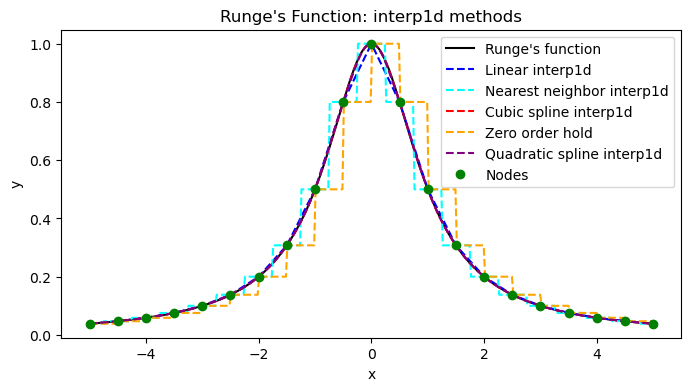

In [24]:
from scipy.interpolate import interp1d

# Define Runge's function
def runge(x):
    return 1 / (1 + x**2)

# Choose interpolation nodes and dense evaluation points
x_nodes = np.linspace(-5, 5, 21)
y_nodes = runge(x_nodes)
x_dense = np.linspace(-5, 5, 400)
y_true = runge(x_dense)

#nearest neighbor interpolation
f_nearest = interp1d(x_nodes, y_nodes, kind='nearest')
y_nearest = f_nearest(x_dense)
#zero order hold
f_zero = interp1d(x_nodes, y_nodes, kind='zero')
y_zero = f_zero(x_dense)

# Linear interpolation
f_linear = interp1d(x_nodes, y_nodes, kind='linear')
y_linear = f_linear(x_dense)

# Quadratic interpolation
f_quad = interp1d(x_nodes, y_nodes, kind='quadratic')
y_quad = f_quad(x_dense)

# Cubic spline interpolation
f_cubic = interp1d(x_nodes, y_nodes, kind='cubic')
y_cubic = f_cubic(x_dense)

plt.figure(figsize=(8, 4))
plt.plot(x_dense, y_true, label="Runge's function", color='black')
plt.plot(x_dense, y_linear, '--', label='Linear interp1d', color='blue')
plt.plot(x_dense, y_nearest, '--', label='Nearest neighbor interp1d', color='cyan')
plt.plot(x_dense, y_cubic, '--', label='Cubic spline interp1d', color='red')
plt.plot(x_dense, y_zero, '--', label='Zero order hold', color='orange')
plt.plot(x_dense, y_quad, '--', label='Quadratic spline interp1d', color='purple')
plt.plot(x_nodes, y_nodes, 'o', label='Nodes', color='green')
plt.xlabel('x')
plt.ylabel('y')
plt.title("Runge's Function: interp1d methods")
plt.legend()
plt.show()

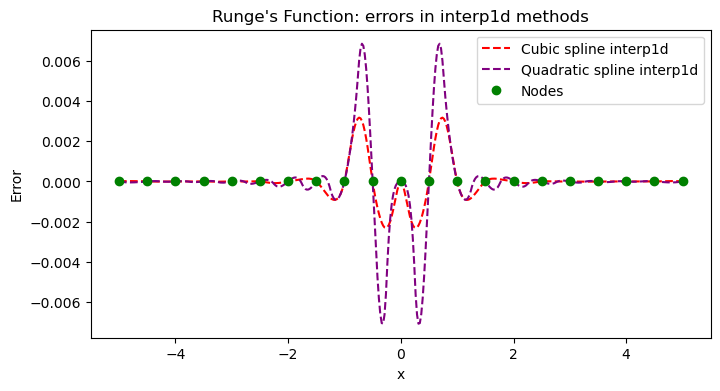

In [25]:
plt.figure(figsize=(8, 4))

#plt.plot(x_dense, y_linear-y_true, '--', label='Linear interp1d', color='blue')
#plt.plot(x_dense, y_nearest-y_true, '--', label='Nearest neighbor interp1d', color='cyan')
plt.plot(x_dense, y_cubic-y_true, '--', label='Cubic spline interp1d', color='red')
#plt.plot(x_dense, y_zero-y_true, '--', label='Zero order hold', color='orange')
plt.plot(x_dense, y_quad-y_true, '--', label='Quadratic spline interp1d', color='purple')
plt.plot(x_nodes, 0*y_nodes, 'o', label='Nodes', color='green')
plt.xlabel('x')
plt.ylabel('Error')
plt.title("Runge's Function: errors in interp1d methods")
plt.legend()
plt.show()